# 04 — Model M3: RCNN na części rzeczywistej i urojonej STFT

Drugi model kontrolny. Otrzymuje pełną informację zawartą w widmie zespolonym,
przekazaną jako dwa kanały wejściowe, przetwarza ją jednak w arytmetyce
rzeczywistej. Różnica względem modelu M2 odzwierciedla wpływ udostępnienia
informacji fazowej.

| | |
|---|---|
| wejście | `2 × 257 × 101` |
| parametry | 554 439 |
| UAR (nagrania) | 0,6001 ± 0,0053 |

## 1. Konfiguracja

In [ ]:
from pathlib import Path

# ---------- ścieżki ----------
ON_KAGGLE = Path("/kaggle/input").exists()
DATA = (Path("/kaggle/input/datasets/julkagromna/ser-processed") if ON_KAGGLE
        else Path("../data/processed"))
WORK = Path("/kaggle/working") if ON_KAGGLE else Path("../results")

# ---------- sygnał ----------
SR = 16000
SEG_SEC = 1.0
SEG_LEN = int(SEG_SEC * SR)

# ---------- STFT ----------
N_FFT, WIN_LENGTH, HOP_LENGTH = 512, 400, 160
WINDOW, CENTER = "hann", True
N_FRAMES = SEG_LEN // HOP_LENGTH + 1     
N_BINS = N_FFT // 2 + 1                 

# ---------- reprezentacja rzeczywista ----------
N_MELS, N_MFCC, FMIN, FMAX = 64, 40, 20, 8000
POWER_COMPRESSION = 0.3
N_IN = 2

# ---------- klasy ----------
EMOTIONS = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]
EMOTION_PL = {"ANG": "złość", "DIS": "wstręt", "FEA": "strach",
              "HAP": "radość", "NEU": "neutralny", "SAD": "smutek"}
LABEL2ID = {e: i for i, e in enumerate(EMOTIONS)}
ID2LABEL = {i: e for e, i in LABEL2ID.items()}
N_CLASSES = len(EMOTIONS)



In [ ]:
import sys, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

here = Path.cwd()
for cand in [here, *here.parents]:
    if (cand / "config.py").exists():
        sys.path.insert(0, str(cand)); break


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATS = WORK / "feats_m3"
RESULTS = WORK / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
FEATS.mkdir(parents=True, exist_ok=True)

# --- hiperparametry ---
BATCH_SIZE = 64
MAX_EPOCHS = 100
PATIENCE = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
SEEDS = [42, 43, 44, 45, 46]
NUM_WORKERS = 2        # Windows/Jupyter: 0; Kaggle/Linux: 2-4

print("urzadzenie:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU       :", torch.cuda.get_device_name(0))

urzadzenie: cuda
GPU       : Tesla T4


In [8]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## 2. Ekstrakcja cech

Część rzeczywista i urojona skompresowanego widma, przekazane jako dwa kanały.
Kompresja modyfikuje wyłącznie moduł, pozostawiając kąt fazowy niezmieniony.

In [ ]:
def wav_to_spec(y):
    Z = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH,
                     win_length=WIN_LENGTH, window=WINDOW, center=CENTER)
    mag = np.maximum(np.abs(Z), 1e-8)
    Zc = Z * (mag ** (POWER_COMPRESSION - 1.0))
    return np.stack([Zc.real, Zc.imag]).astype(np.float32)

def extract_split(split: str) -> Path:
    out = FEATS / f"reim_{split}.npy"
    if out.exists():
        print(f"{split}: cechy juz istnieja, pomijam")
        return out
    X = np.load(DATA  / f"X_{split}.npy", mmap_mode="r")
    n = X.shape[0]
    arr = np.lib.format.open_memmap(out, mode="w+", dtype=np.float32,
                                    shape=(n, N_IN, N_BINS, N_FRAMES))
    t0 = time.time()
    for i in range(n):
        y = np.asarray(X[i], dtype=np.float32)
        if y.dtype != np.float32 or np.abs(y).max() > 1.5:  
            y = y.astype(np.float32) / 32767.0
        arr[i] = wav_to_spec(y)
        if (i + 1) % 2000 == 0:
            print(f"  {split}: {i+1}/{n}  ({time.time()-t0:.0f} s)")
    arr.flush()
    print(f"{split}: gotowe, {n} segmentow w {time.time()-t0:.0f} s -> {out.name}")
    return out


manifest = pd.read_csv(DATA / "manifest.csv")
for s in ["train", "val", "test"]:
    extract_split(s)

  train: 2000/21151  (17 s)
  train: 4000/21151  (21 s)
  train: 6000/21151  (24 s)
  train: 8000/21151  (28 s)
  train: 10000/21151  (31 s)
  train: 12000/21151  (35 s)
  train: 14000/21151  (38 s)
  train: 16000/21151  (42 s)
  train: 18000/21151  (46 s)
  train: 20000/21151  (50 s)
train: gotowe, 21151 segmentow w 65 s -> reim_train.npy
  val: 2000/4686  (4 s)
  val: 4000/4686  (8 s)
val: gotowe, 4686 segmentow w 13 s -> reim_val.npy
  test: 2000/4731  (4 s)
  test: 4000/4731  (8 s)
test: gotowe, 4731 segmentow w 13 s -> reim_test.npy


## 3. Normalizacja

Statystyki wyznaczane wyłącznie na zbiorze treningowym, niezależnie dla każdego
kanału i współczynnika.

In [ ]:
stats_path = FEATS / "norm_stats.npz"

if stats_path.exists():
    st = np.load(stats_path)
    MEAN, STD = st["mean"], st["std"]
else:
    Xtr = np.load(FEATS / "reim_train.npy", mmap_mode="r")
    MEAN = Xtr.mean(axis=(0, 3), keepdims=True)          
    STD = Xtr.std(axis=(0, 3), keepdims=True) + 1e-8
    np.savez(stats_path, mean=MEAN, std=STD)

MEAN_T = torch.from_numpy(MEAN[0]).float()
STD_T = torch.from_numpy(STD[0]).float()
print("ksztalt statystyk:", MEAN.shape)
print("zakres srednich  :", float(MEAN.min()), "...", float(MEAN.max()))

ksztalt statystyk: (1, 2, 257, 1)
zakres srednich  : -0.017183175310492516 ... 0.01091262698173523


## 4. Zbiory danych i wagi klas

Wagi klas wyznaczane automatycznie według zależności `w_k = n / (K · n_k)`,
identycznie dla wszystkich modeli.

In [ ]:
class GPUSplit:
    def __init__(self, split):
        X = np.load(FEATS / f"reim_{split}.npy")          
        X = torch.from_numpy(X).float()
        X = (X - MEAN_T) / STD_T                          
        self.X = X.to(DEVICE)
        self.meta = manifest[manifest.split == split].sort_values("idx").reset_index(drop=True)
        self.y = torch.from_numpy(self.meta.label.values.astype(np.int64)).to(DEVICE)
        assert len(self.X) == len(self.y), "niezgodność cech i manifestu"

    def __len__(self):
        return len(self.y)


def batches(d, bs, shuffle=False, generator=None, drop_last=False):
    n = len(d)
    idx = torch.randperm(n, generator=generator) if shuffle else torch.arange(n)
    idx = idx.to(DEVICE)
    stop = n - (n % bs if drop_last else 0)
    for i in range(0, stop, bs):
        j = idx[i:i + bs]
        yield d.X[j], d.y[j]


ds = {s: GPUSplit(s) for s in ["train", "val", "test"]}
for s, d in ds.items():
    gb = d.X.element_size() * d.X.nelement() / 1e9
    print(f"{s:5s}: {len(d):6d} segmentów | {d.meta.file_id.nunique():5d} nagrań | {gb:.2f} GB na GPU")

train:  21151 segmentów |  5157 nagrań | 4.39 GB na GPU
val  :   4686 segmentów |  1142 nagrań | 0.97 GB na GPU
test :   4731 segmentów |  1142 nagrań | 0.98 GB na GPU


In [ ]:
# wagi klas: n / (k * n_klasy) - metoda identyczna dla wszystkich modeli
counts = np.bincount(ds["train"].y.cpu().numpy(), minlength=N_CLASSES)
weights = counts.sum() / (N_CLASSES * counts)
CLASS_W = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

print(pd.DataFrame({
    "klasa": EMOTIONS,
    "segmentow": counts,
    "waga": weights.round(3),
}).to_string(index=False))

klasa  segmentow  waga
  ANG       3106 1.135
  DIS       4160 0.847
  FEA       3565 0.989
  HAP       3277 1.076
  NEU       3108 1.134
  SAD       3935 0.896


## 5. Architektura

Cztery bloki splotowe, dwukierunkowa warstwa GRU, agregacja z mechanizmem uwagi
oraz moduł decyzyjny. Na wyjściu zwracane są logity; normalizacja softmax
realizowana jest wewnątrz funkcji straty.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, pool):
        super().__init__()
        self.conv = nn.Conv2d(cin, cout, 3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(cout)
        self.pool = nn.MaxPool2d(pool)
        self.drop = nn.Dropout2d(0.1)

    def forward(self, x):
        return self.drop(self.pool(F.relu(self.bn(self.conv(x)))))


class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Linear(dim, 1)

    def forward(self, x):                      
        a = torch.softmax(self.w(x), dim=1)    
        return (x * a).sum(dim=1)              


class RCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, ch=(32, 64, 128, 128), rnn_hidden=128):
        super().__init__()
        pools = [(4, 2), (4, 2), (4, 1), (2, 1)]
        blocks, cin = [], N_IN
        for cout, p in zip(ch, pools):
            blocks.append(ConvBlock(cin, cout, p)); cin = cout
        self.conv = nn.Sequential(*blocks)

        with torch.no_grad():
            dummy = torch.zeros(1, N_IN, N_BINS, N_FRAMES)
            c, f, t = self.conv(dummy).shape[1:]
        self.seq_dim = c * f
        self.seq_len = t

        self.rnn = nn.GRU(self.seq_dim, rnn_hidden, batch_first=True, bidirectional=True)
        self.att = AttentionPool(2 * rnn_hidden)
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(2 * rnn_hidden, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.conv(x)                       
        x = x.permute(0, 3, 1, 2).flatten(2)   
        x, _ = self.rnn(x)
        return self.head(self.att(x))


m = RCNN()
n_par = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"sekwencja po konwolucjach: dlugosc {m.seq_len}, wymiar {m.seq_dim}")
print(f"parametry uczone (rzeczywiste): {n_par:,}")
print(m(torch.zeros(2, N_IN, N_BINS, N_FRAMES)).shape)

sekwencja po konwolucjach: dlugosc 25, wymiar 256
parametry uczone (rzeczywiste): 554,439
torch.Size([2, 6])


## 6. Uczenie i ewaluacja

Pięć niezależnych przebiegów różniących się ziarnem inicjalizacji. Wybór modelu na
podstawie miary UAR na zbiorze walidacyjnym.

In [14]:
@torch.no_grad()
def evaluate(model, d):
    model.eval()
    probs = [torch.softmax(model(xb), 1) for xb, _ in batches(d, 256)]
    return torch.cat(probs).cpu().numpy(), d.y.cpu().numpy()


def train_one(seed, verbose=True):
    set_seed(seed)
    g = torch.Generator(); g.manual_seed(seed)


    model = RCNN().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "max", factor=0.5, patience=5)
    crit = nn.CrossEntropyLoss(weight=CLASS_W)

    hist = {"train_loss": [], "val_loss": [], "val_uar": [], "epoch_time": []}
    best_uar, best_state, bad = -1.0, None, 0

    for ep in range(1, MAX_EPOCHS + 1):
        model.train(); tl, nb, t0 = 0.0, 0, time.time()
        for xb, yb in batches(ds["train"], BATCH_SIZE, shuffle=True,
                              generator=g, drop_last=True):
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            tl += loss.item(); nb += 1
        ep_time = time.time() - t0

        p, y = evaluate(model, ds["val"])
        vl = F.cross_entropy(torch.log(torch.tensor(p) + 1e-9), torch.tensor(y)).item()
        uar = recall_score(y, p.argmax(1), average="macro")

        hist["train_loss"].append(tl / nb)
        hist["val_loss"].append(vl)
        hist["val_uar"].append(uar)
        hist["epoch_time"].append(ep_time)
        sched.step(uar)

        if uar > best_uar:
            best_uar, bad = uar, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1

        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"  ep {ep:3d} | strata {tl/nb} | val UAR {uar:.4f} "
                  f"| najlepsze {best_uar:.4f} | {ep_time:.1f} s")
        if bad >= PATIENCE:
            print(f"  early stopping w epoce {ep}")
            break

    model.load_state_dict(best_state)
    probs_te, y_te = evaluate(model, ds["test"])
    return model, hist, probs_te, y_te

In [15]:
def aggregate(probs, split="test"):
    meta = ds[split].meta
    df = pd.DataFrame(probs, columns=EMOTIONS)
    df["file_id"] = meta.file_id.values
    df["label"] = meta.label.values
    agg = df.groupby("file_id").agg({**{e: "mean" for e in EMOTIONS}, "label": "first"})
    y = agg.label.values
    pred = agg[EMOTIONS].values.argmax(1)
    return y, pred


def metrics(y, pred):
    return {
        "accuracy": float(accuracy_score(y, pred)),
        "uar": float(recall_score(y, pred, average="macro")),
        "macro_f1": float(f1_score(y, pred, average="macro")),
        "f1_per_class": {e: float(v) for e, v in
                         zip(EMOTIONS, f1_score(y, pred, average=None,
                                                    labels=range(N_CLASSES)))},
    }

In [16]:
runs, all_hist = [], []
last_model = last_probs = last_y = None

for seed in SEEDS:
    print(f"\n=== ziarno {seed} ===")
    model, hist, probs, y = train_one(seed)

    seg = metrics(y, probs.argmax(1))
    y_f, pred_f = aggregate(probs)
    utt = metrics(y_f, pred_f)

    runs.append({"seed": seed, "segment": seg, "utterance": utt,
                 "epochs": len(hist["val_uar"]),
                 "mean_epoch_time": float(np.mean(hist["epoch_time"])),
                 "pred_utterance": pred_f.tolist(),
                 "true_utterance": y_f.tolist(),
                 "confusion_segment": confusion_matrix(y, probs.argmax(1)).tolist(),
                 "confusion_utterance": confusion_matrix(y_f, pred_f).tolist()})
    all_hist.append(hist)
    last_model, last_probs, last_y = model, probs, y

    print(f"  segmenty : acc {seg['accuracy']:.4f} | UAR {seg['uar']:.4f} | F1 {seg['macro_f1']:.4f}")
    print(f"  nagrania : acc {utt['accuracy']:.4f} | UAR {utt['uar']:.4f} | F1 {utt['macro_f1']:.4f}")


=== ziarno 42 ===
  ep   1 | strata 1.5863815932562857 | val UAR 0.3822 | najlepsze 0.3822 | 16.6 s
  ep   5 | strata 1.3563095916401255 | val UAR 0.4588 | najlepsze 0.4588 | 15.9 s
  ep  10 | strata 1.1652573206207968 | val UAR 0.4841 | najlepsze 0.4846 | 15.7 s
  ep  15 | strata 0.9869877502773747 | val UAR 0.4940 | najlepsze 0.5048 | 15.8 s
  ep  20 | strata 0.8353241362354972 | val UAR 0.4974 | najlepsze 0.5052 | 15.8 s
  ep  25 | strata 0.6170576878569343 | val UAR 0.4994 | najlepsze 0.5061 | 15.8 s
  ep  30 | strata 0.5295620242754618 | val UAR 0.4926 | najlepsze 0.5098 | 15.7 s
  ep  35 | strata 0.4396380433078968 | val UAR 0.5064 | najlepsze 0.5098 | 15.7 s
  ep  40 | strata 0.39489114718003704 | val UAR 0.5082 | najlepsze 0.5098 | 15.7 s
  early stopping w epoce 41
  segmenty : acc 0.5064 | UAR 0.5165 | F1 0.5121
  nagrania : acc 0.6086 | UAR 0.6095 | F1 0.6060

=== ziarno 43 ===
  ep   1 | strata 1.5826071280421632 | val UAR 0.3923 | najlepsze 0.3923 | 15.8 s
  ep   5 | stra

## 7. Wyniki

In [17]:
def summarize(runs, level):
    rows = {k: [r[level][k] for r in runs] for k in ["accuracy", "uar", "macro_f1"]}
    return pd.DataFrame({
        "metryka": list(rows),
        "srednia": [np.mean(v) for v in rows.values()],
        "odch. std": [np.std(v) for v in rows.values()],
    }).round(4)

print("=== poziom segmentow ===")
display(summarize(runs, "segment"))
print("=== poziom nagran ===")
display(summarize(runs, "utterance"))
print(f"\nsredni czas epoki: {np.mean([r['mean_epoch_time'] for r in runs]):.1f} s")

=== poziom segmentow ===


,metryka,srednia,odch. std
0,accuracy,0.5019,0.0038
1,uar,0.5154,0.0045
2,macro_f1,0.5036,0.0049


=== poziom nagran ===


,metryka,srednia,odch. std
0,accuracy,0.5993,0.0053
1,uar,0.6001,0.0053
2,macro_f1,0.5924,0.0080



sredni czas epoki: 15.7 s


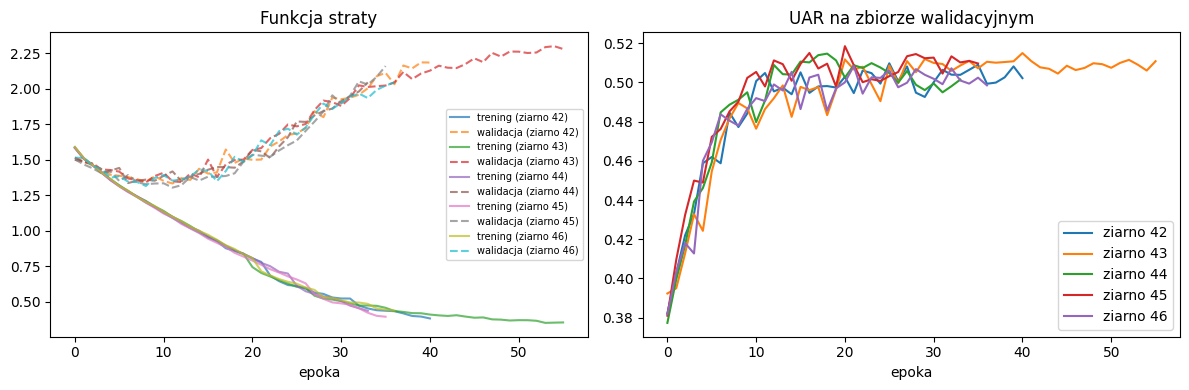

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for h, s in zip(all_hist, SEEDS):
    ax[0].plot(h["train_loss"], label=f"trening (ziarno {s})", alpha=.7)
    ax[0].plot(h["val_loss"], "--", label=f"walidacja (ziarno {s})", alpha=.7)
    ax[1].plot(h["val_uar"], label=f"ziarno {s}")
ax[0].set_title("Funkcja straty"); ax[0].set_xlabel("epoka"); ax[0].legend(fontsize=7)
ax[1].set_title("UAR na zbiorze walidacyjnym"); ax[1].set_xlabel("epoka"); ax[1].legend()
plt.tight_layout()
plt.savefig(RESULTS / "m3_reim_krzywe_uczenia.png", dpi=300, bbox_inches="tight")
plt.show()

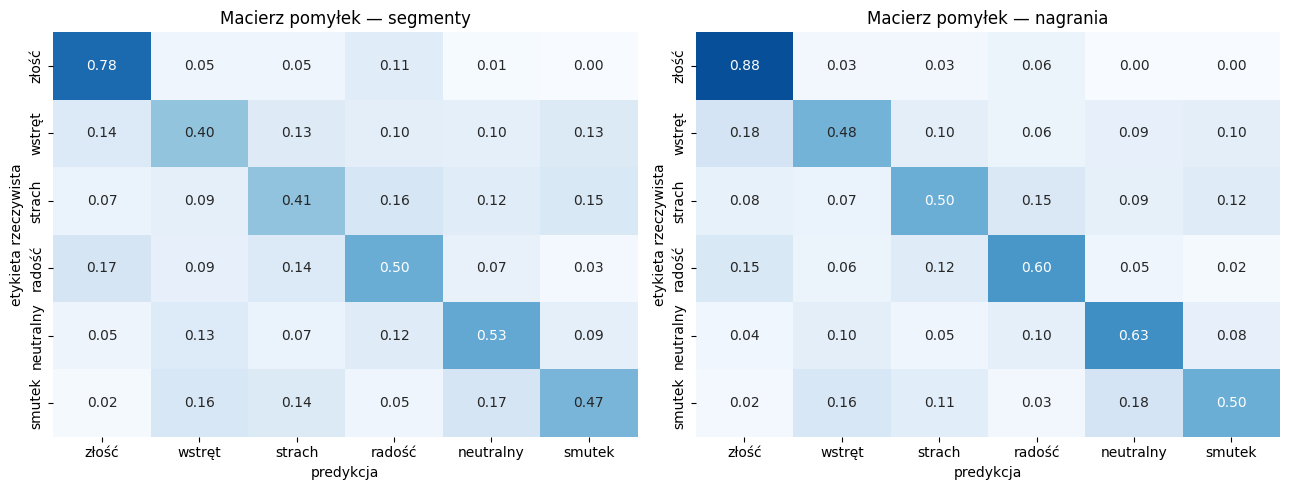

macierz uśredniona z 5 przebiegów
maks. odchylenie std na przekątnej: 0.065
klasa                 precyzja           czułość                F1
złość            0.660±0.044     0.881±0.039     0.753±0.015
wstręt           0.543±0.008     0.478±0.034     0.508±0.018
strach           0.560±0.041     0.501±0.053     0.525±0.024
radość           0.620±0.028     0.604±0.033     0.611±0.023
neutralny        0.583±0.033     0.635±0.065     0.604±0.014
smutek           0.623±0.037     0.503±0.049     0.554±0.025
średnia          0.598            0.600            0.592


In [ ]:
labels_pl = [EMOTION_PL[e] for e in EMOTIONS]

def usrednij(klucz):
    cms = np.array([r[klucz] for r in runs], dtype=float)
    cmn = np.stack([c / c.sum(1, keepdims=True) for c in cms])
    return cmn.mean(0), cmn.std(0)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, (klucz, tt) in zip(ax, [("confusion_segment", "segmenty"),
                               ("confusion_utterance", "nagrania")]):
    cm, _ = usrednij(klucz)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=labels_pl, yticklabels=labels_pl, ax=a, cbar=False)
    a.set_title(f"Macierz pomyłek — {tt}")
    a.set_xlabel("predykcja"); a.set_ylabel("etykieta rzeczywista")
plt.tight_layout()
plt.savefig(RESULTS / "m3_reim_macierz_pomylek.png", dpi=300, bbox_inches="tight")
plt.show()

_, cm_std = usrednij("confusion_utterance")
print(f"macierz uśredniona z {len(runs)} przebiegów")
print(f"maks. odchylenie std na przekątnej: {cm_std.diagonal().max():.3f}")

# raport klasyfikacji: srednia i odchylenie po przebiegach
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1 = [], [], []
for r in runs:
    p_, r_, f_, _ = precision_recall_fscore_support(
        np.array(r["true_utterance"]), np.array(r["pred_utterance"]),
        labels=range(N_CLASSES), zero_division=0)
    prec.append(p_); rec.append(r_); f1.append(f_)
prec, rec, f1 = np.array(prec), np.array(rec), np.array(f1)

print(f"{'klasa':12s}{'precyzja':>18s}{'czułość':>18s}{'F1':>18s}")
for i, e in enumerate(labels_pl):
    print(f"{e:12s}{prec[:,i].mean():>10.3f}±{prec[:,i].std():.3f}"
          f"{rec[:,i].mean():>10.3f}±{rec[:,i].std():.3f}"
          f"{f1[:,i].mean():>10.3f}±{f1[:,i].std():.3f}")
print(f"{'średnia':12s}{prec.mean():>10.3f}{'':7s}{rec.mean():>10.3f}{'':7s}{f1.mean():>10.3f}")

## 8. Koszt obliczeniowy

Pomiar latencji przy rozmiarze partii równym jeden, po dwudziestu uruchomieniach
rozgrzewkowych, z synchronizacją akceleratora.

In [ ]:
model = last_model.eval()
n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)

x = torch.randn(1, N_IN, N_BINS, N_FRAMES, device=DEVICE)
with torch.no_grad():                       
    for _ in range(20):
        model(x)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

t0 = time.time()
with torch.no_grad():
    for _ in range(200):
        model(x)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
latency = (time.time() - t0) / 200 * 1000

complexity = {
    "params_real": int(n_par),
    "latency_ms": float(latency),
    "mean_epoch_time_s": float(np.mean([r["mean_epoch_time"] for r in runs])),
    "device": str(DEVICE),
}
print(json.dumps(complexity, indent=2))

{
  "params_real": 554439,
  "latency_ms": 1.3872897624969482,
  "mean_epoch_time_s": 15.738551962734675,
  "device": "cuda"
}


## 9. Zapis wyników

In [ ]:
out = {
    "model": "m3_reim",
    "representation": "Re/Im STFT^0.3, reprezentacja rzeczywista",
    "input_shape": [N_IN, N_BINS, N_FRAMES],
    "seeds": SEEDS,
    "runs": runs,
    "complexity": complexity,
    "history": all_hist,
    "confusion_utterance": confusion_matrix(y_f, pred_f).tolist(),
    "emotions": EMOTIONS,
}
with open(RESULTS / "m3_reim_5seeds.json", "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2, ensure_ascii=False)

torch.save(last_model.state_dict(), RESULTS / "m3_reim_5seeds.pt")
print(f"zapisano: {RESULTS/'m3_reim_5seeds.json'}")
print(f"zapisano: {RESULTS/'m3_reim_5seeds.pt'}")

zapisano: /kaggle/working/results/real.json
zapisano: /kaggle/working/results/real_rcnn.pt
